# Terrain Modification Analysis


In [1]:
# Setup and imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from ras_commander import RasExamples, init_ras_project
from ras_commander.terrain import RasTerrainModWriter

# Optional: RasTerrainMod for reading terrain with modifications applied (requires pythonnet)
try:
    from ras_commander.terrain import RasTerrainMod
    bridge_ok = RasTerrainMod.setup_gdal_bridge()
    print(f'RasTerrainMod available (GDAL bridge: {bridge_ok})')
    HAS_TERRAIN_MOD = bridge_ok
except (ImportError, OSError) as e:
    print(f'RasTerrainMod not available: {e}')
    print('Terrain modification WRITING will work, but reading/sampling requires pythonnet + HEC-RAS 6.6+')
    HAS_TERRAIN_MOD = False

print('RasTerrainModWriter imported successfully')

RasTerrainMod available (GDAL bridge: True)
RasTerrainModWriter imported successfully


## Step 1: Setup

RasTerrainModWriter can create terrain modifications without pythonnet or the GDAL bridge.
If you want to SAMPLE the modified terrain (get_terrain_profile, get_terrain_volume_elevation),
you need RasTerrainMod which requires pythonnet and HEC-RAS 6.6+ RasMapperLib.dll.

In [2]:
# GDAL bridge setup (only needed for terrain sampling, not for writing modifications)
if HAS_TERRAIN_MOD:
    print('GDAL bridge is ready for terrain sampling')
else:
    print('Skipping GDAL bridge - terrain writing still works')

GDAL bridge is ready for terrain sampling


## Step 2: Create Project with Terrain Modification

We will extract the BaldEagleCrkMulti2D example project, read its river centerline,
and add a channel terrain modification along that centerline. This demonstrates the
full workflow of programmatically creating terrain modifications.

In [3]:
# Extract example project
project_path = RasExamples.extract_project('BaldEagleCrkMulti2D', suffix='930_terrainmod')
print(f'Project: {project_path}')

# Find terrain HDF and rasmap
terrain_hdf = list((project_path / 'Terrain').glob('*.hdf'))[0]
rasmap_path = list(project_path.glob('*.rasmap'))[0]
print(f'Terrain: {terrain_hdf.name}')
print(f'Rasmap: {rasmap_path.name}')

# Read river centerline from geometry HDF (g06 has centerlines)
geom_hdf = project_path / 'BaldEagleDamBrk.g06.hdf'
with h5py.File(geom_hdf, 'r') as f:
    centerline_pts = f['Geometry/River Centerlines/Polyline Points'][:]
print(f'River centerline: {len(centerline_pts)} points')

# Verify files exist
assert terrain_hdf.exists(), f'Terrain not found: {terrain_hdf}'
assert rasmap_path.exists(), f'Rasmap not found: {rasmap_path}'
print()
print(f'Project: {project_path.name}')
print(f'Rasmap: {rasmap_path.name}')
print(f'Geometry: {geom_hdf.name}')

Project: <workspace>\examples\example_projects\BaldEagleCrkMulti2D_930_terrainmod
Terrain: Terrain50.hdf
Rasmap: BaldEagleDamBrk.rasmap
River centerline: 383 points

Project: BaldEagleCrkMulti2D_930_terrainmod
Rasmap: BaldEagleDamBrk.rasmap
Geometry: BaldEagleDamBrk.g06.hdf


## Step 3: Add Channel Terrain Modification

Use  to add a channel modification along the river centerline.
This writes to both the terrain HDF (modification geometry) and the .rasmap XML (display metadata).

The channel modification uses "TakeLower" mode - the terrain is lowered where the trapezoidal channel cross-section is below the existing ground surface.

In [4]:
# Add a channel terrain modification along the river centerline
# Use the first 100 points of the centerline as the channel alignment
channel_alignment = centerline_pts[:100]

# Add a modification group and channel modification
RasTerrainModWriter.add_modification_group(terrain_hdf, rasmap_path)

RasTerrainModWriter.add_channel_modification(
    terrain_hdf_path=terrain_hdf,
    rasmap_path=rasmap_path,
    name="River Channel",
    polyline_points=channel_alignment,
    width=100.0,       # 100 ft bottom width
    depth=15.0,        # 15 ft depth
    left_slope=3.0,    # 3H:1V side slopes
    right_slope=3.0,
    max_extent=200.0,  # Maximum lateral extent
)

# Verify the modification was written
with h5py.File(terrain_hdf, "r") as f:
    mods = f["Modifications"]
    for mod_name in mods:
        grp = mods[mod_name]
        n_pts = len(grp["Polyline Points"])
        width_val = grp["Attributes"]["Top Width"][0]
        print(f"Modification: {mod_name}")
        mod_type = grp.attrs['Type']
        mod_sub = grp.attrs['Subtype']
        print(f"  Type: {mod_type}, Subtype: {mod_sub}")
        print(f"  Alignment: {n_pts} points")
        print(f"  Width: {width_val} ft")

# Verify rasmap was updated
import xml.etree.ElementTree as ET
tree = ET.parse(rasmap_path)
for mg in tree.findall('.//Layer[@Type="ElevationModificationGroup"]'):
    group_name = mg.get('Name')
    print(f"Rasmap modification group: {group_name}")
    for child in mg.findall("Layer"):
        child_name = child.get('Name')
        child_type = child.get('Type')
        print(f"  Layer: {child_name} (Type={child_type})")

Modification: River Channel
  Type: b'Channel', Subtype: b'Channel'
  Alignment: 100 points
  Width: 100.0 ft
Rasmap modification group: Modifications
  Layer: River Channel (Type=GroundLineModificationLayer)


## Step 3: Get Terrain Extent

Query the terrain bounding box to understand the project domain.

In [5]:
try:
    if HAS_TERRAIN_MOD:
        extent = RasTerrainMod.get_terrain_extent(str(rasmap_path), str(geom_hdf))
        print(f"Success: {extent['success']}")
        print(f"X range: {extent['min_x']:,.0f} to {extent['max_x']:,.0f}")
        print(f"Y range: {extent['min_y']:,.0f} to {extent['max_y']:,.0f}")
    else:
        print("Skipping terrain extent (pythonnet not available)")
except Exception as e:
    print(f"Terrain extent sampling failed: {e}")
    print("This is expected if pythonnet/RasMapperLib is not fully configured.")
    HAS_TERRAIN_MOD = False

Success: True
X range: 1,834,327 to 2,149,836
Y range: 162,919 to 414,873


## Step 4: Sample Terrain Profile with Modifications

Sample terrain along a polyline. The returned elevations include ALL terrain modifications (channels, levees, polygon overrides) that are defined in the terrain HDF referenced by the .rasmap file.

This is equivalent to cutting a cross-section through the terrain in RASMapper â€” but without opening the GUI.

In [6]:
try:
    if HAS_TERRAIN_MOD:
        x_profile = centerline_pts[:50, 0].tolist()
        y_profile = centerline_pts[:50, 1].tolist()
        profile = RasTerrainMod.get_terrain_profile(
            str(rasmap_path), str(geom_hdf),
            x_coords=x_profile, y_coords=y_profile
        )
        print(f"Profile: {len(profile)} points sampled")
        print(f"Elevation range: {profile['elevation'].min():.1f} to {profile['elevation'].max():.1f}")
    else:
        print("Skipping terrain profile (pythonnet not available)")
except Exception as e:
    print(f"Terrain profile sampling failed: {e}")
    HAS_TERRAIN_MOD = False

Profile: 2961 points sampled
Elevation range: 624.9 to 684.5


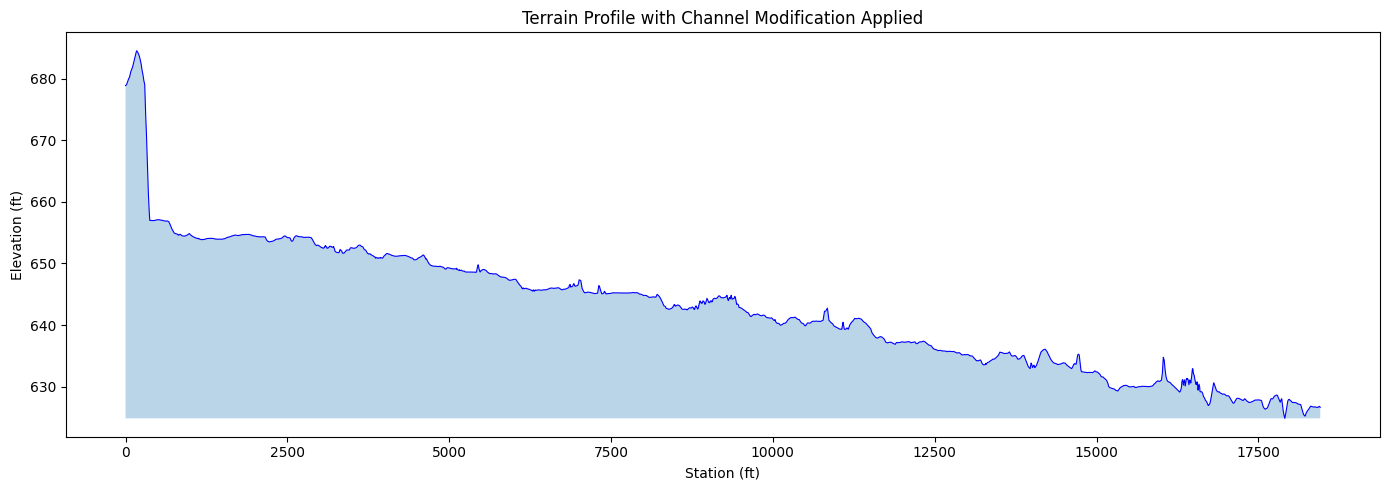

In [7]:
if HAS_TERRAIN_MOD and 'profile' in dir():
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(profile['station'], profile['elevation'], 'b-', linewidth=0.8)
    ax.fill_between(profile['station'], profile['elevation'].min(), profile['elevation'], alpha=0.3)
    ax.set_xlabel('Station (ft)')
    ax.set_ylabel('Elevation (ft)')
    ax.set_title('Terrain Profile with Channel Modification Applied')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping profile plot (no data)")

## Step 5: Elevation-Volume Curve for a Polygon

Compute the elevation-volume relationship within a polygon area. This is essential for:
- Detention pond sizing
- Storage volume calculations
- No-net-fill compliance

The volumes reflect the terrain WITH modifications â€” so if you've modeled a pond with terrain modifications, the volume curve includes the pond excavation.

In [8]:
try:
    if HAS_TERRAIN_MOD:
        cx = centerline_pts[25, 0]
        cy = centerline_pts[25, 1]
        hw = 500.0
        poly_x = [cx-hw, cx+hw, cx+hw, cx-hw, cx-hw]
        poly_y = [cy-hw, cy-hw, cy+hw, cy+hw, cy-hw]
        ev_cuft = RasTerrainMod.get_terrain_volume_elevation(
            str(rasmap_path), str(geom_hdf),
            x_coords=poly_x, y_coords=poly_y
        )
        print(f"Volume-elevation: {len(ev_cuft)} points")
    else:
        print("Skipping elevation-volume (pythonnet not available)")
except Exception as e:
    print(f"Volume calculation failed: {e}")
    HAS_TERRAIN_MOD = False

Volume-elevation: 42 points


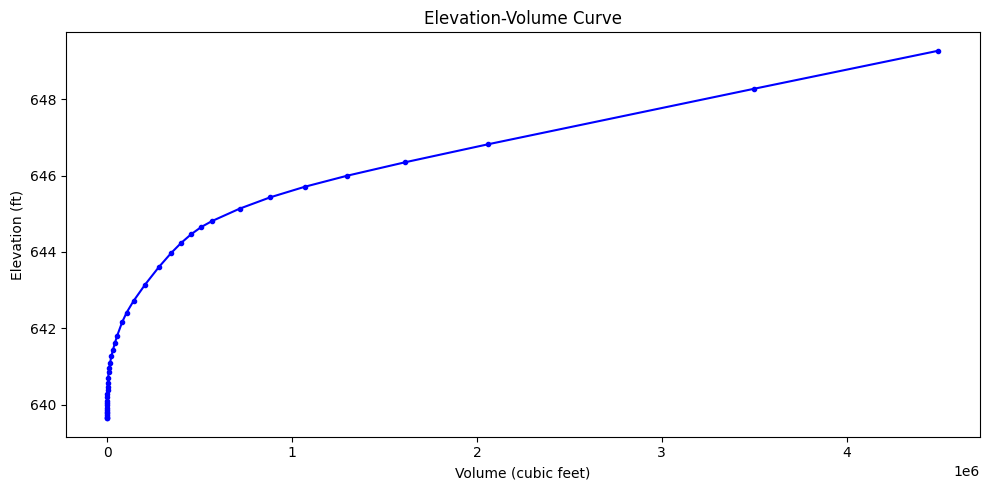

In [9]:
if HAS_TERRAIN_MOD and 'ev_cuft' in dir():
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ev_cuft['volume'], ev_cuft['elevation'], 'b-o', markersize=3)
    ax.set_xlabel('Volume (cubic feet)')
    ax.set_ylabel('Elevation (ft)')
    ax.set_title('Elevation-Volume Curve')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping volume plot (no data)")

## Step 6: Elevation-Volume Table

Display the full elevation-volume table for engineering review.

In [10]:
if HAS_TERRAIN_MOD and 'ev_cuft' in dir():
    summary = ev_cuft.copy()
    print(summary.to_string(index=False))
else:
    print("Skipping volume table (no data)")

 elevation       volume
639.638489 0.000000e+00
639.658630 4.393459e-02
639.680786 1.918986e-01
639.713196 7.026107e-01
639.770264 3.113317e+00
639.812744 7.307600e+00
639.850281 1.391868e+01
639.920776 3.764766e+01
639.979553 7.470703e+01
640.035034 1.320834e+02
640.086304 2.106888e+02
640.185669 4.456124e+02
640.287842 8.289766e+02
640.374268 1.289607e+03
640.464172 1.924101e+03
640.552063 2.718080e+03
640.708496 4.662321e+03
640.847412 7.194930e+03
640.960999 1.021646e+04
641.100464 1.494644e+04
641.262329 2.179879e+04
641.433777 3.046902e+04
641.604431 4.034296e+04
641.807007 5.341897e+04
642.158081 7.995259e+04
642.412354 1.045090e+05
642.717834 1.421463e+05
643.144714 2.043206e+05
643.602905 2.785922e+05
643.973694 3.456709e+05
644.237671 3.996731e+05
644.468689 4.547113e+05
644.654114 5.083247e+05
644.809082 5.660972e+05
645.135315 7.160244e+05
645.432068 8.812095e+05
645.710144 1.069195e+06
646.000366 1.299195e+06
646.349731 1.610025e+06
646.825134 2.062250e+06
648.275513 3.497

## Key Takeaways

- **** creates terrain modifications programmatically (channel, levee, polygon)
  - Writes to both terrain HDF (/Modifications/) and .rasmap XML
  - No pythonnet or RasMapperLib required for writing
  - Supports modification groups for organizing multiple modifications
- **** (optional) provides headless terrain SAMPLING with modifications applied
  - Requires pythonnet + HEC-RAS 6.6+ RasMapperLib.dll
  - Used for cut/fill analysis, elevation-volume curves, terrain profiles
- The dual-storage architecture (HDF + XML) is handled automatically by both classes